# Retail Operations RAG (Maison Kurt) : démarche d'évaluation

Ce notebook montre la démarche du projet : découper le corpus, indexer, **mesurer la recherche séparément de la génération**, puis vérifier le garde-fou de refus. Les métriques viennent des annotations passage-question de `evaluation.json` et sont les mêmes que celles de `evaluate.py`.

> La documentation Maison Kurt est entièrement fictive. C'est un POC, pas un produit. Aucune précision de génération n'est revendiquée : seule la recherche est mesurée.

In [1]:
import json, sys
from pathlib import Path

import faiss
import matplotlib.pyplot as plt
import numpy as np
from sentence_transformers import SentenceTransformer

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
from retail_rag.core import (
    PROMPT, REFUSAL, deterministic_answer_check, format_context, load_passages,
    retrieval_metrics, should_refuse, validate_citations,
)

## 1. Corpus : un passage = une section citable

Chaque guide est découpé sur ses titres `##`. Un passage est ainsi une règle complète, avec un identifiant stable `fichier.md#section-N` que le LLM devra citer. Un découpage par taille pourrait couper une règle de son exception.

In [2]:
passages = load_passages(ROOT / "data")
print(len(passages), "passages,", len({p.source for p in passages}), "guides")
lengths = [len(p.text) for p in passages]
print("longueur (caractères) : min", min(lengths), "| médiane", int(np.median(lengths)), "| max", max(lengths))
for p in passages[:3]:
    print("-", p.id, "|", p.heading)

50 passages, 8 guides
longueur (caractères) : min 171 | médiane 256 | max 546
- guide_caisse.md#section-1 | 1. Annulation d'une vente en cours
- guide_caisse.md#section-2 | 2. Duplicata de ticket de caisse
- guide_caisse.md#section-3 | 3. Erreur de prix constatée en caisse


## 2. Embeddings et index

`multilingual-e5-small` (multilingue, 384 dimensions, exécutable sur CPU). Ce modèle attend les préfixes `passage:` pour les documents et `query:` pour les questions ; l'application (`build_e5_embeddings`) et l'évaluation utilisent les mêmes. Vecteurs normalisés, donc produit scalaire = similarité cosinus.

In [3]:
model = SentenceTransformer("intfloat/multilingual-e5-small")
passage_vectors = model.encode([f"passage: {p.text}" for p in passages], normalize_embeddings=True)
index = faiss.IndexFlatIP(passage_vectors.shape[1])
index.add(passage_vectors)
print("index :", index.ntotal, "vecteurs de dimension", passage_vectors.shape[1])

def search(question, k):
    q = model.encode([f"query: {question}"], normalize_embeddings=True)
    scores, idx = index.search(q, k)
    return [(passages[i].id, float(s)) for i, s in zip(idx[0], scores[0])]

for pid, s in search("Quel est le délai de retour d'un article soldé ?", 3):
    print(f"{s:.3f}  {pid}")

index : 50 vecteurs de dimension 384
0.918  guide_retours_echanges.md#section-3
0.899  guide_retours_echanges.md#section-1
0.888  guide_retours_echanges.md#section-2


## 3. Jeu d'évaluation annoté

65 questions : 52 dans le périmètre, avec les passages pertinents annotés, et 13 hors périmètre, réservées à l'étude du refus. Parmi les 52, **26 sont « difficiles »** : reformulations sans les mots du guide, questions ambiguës, questions qui demandent deux passages. Limite : toutes ont été écrites par l'auteur du corpus (biais possible).

In [4]:
dataset = json.loads((ROOT / "evaluation.json").read_text(encoding="utf-8"))
scoped = [d for d in dataset if d["in_scope"]]
print(len(dataset), "questions |", len(scoped), "in-scope |", len(dataset) - len(scoped), "hors périmètre")
hard = [i for i, d in enumerate(scoped) if d.get("level") == "hard"]
print(len(hard), "questions difficiles parmi les", len(scoped))
print(json.dumps(scoped[0], ensure_ascii=False, indent=2))
print(json.dumps(scoped[hard[0]], ensure_ascii=False, indent=2))

65 questions | 52 in-scope | 13 hors périmètre
26 questions difficiles parmi les 52
{
  "id": "retour-standard-delai",
  "question": "Quel est le délai de retour d'un article standard acheté en magasin ?",
  "relevant_passage_ids": [
    "guide_retours_echanges.md#section-1"
  ],
  "expected_terms": [
    "30 jours"
  ],
  "in_scope": true
}
{
  "id": "h-colis-abime",
  "question": "Mon client a reçu un paquet tout abîmé, je lui rends son argent tout de suite ?",
  "relevant_passage_ids": [
    "guide_commandes_en_ligne.md#section-4"
  ],
  "expected_terms": [
    "avant vérification"
  ],
  "in_scope": true,
  "level": "hard"
}


## 4. Évaluation de la recherche : Recall@k et MRR@k

Recall@k : part des passages pertinents présents dans les k premiers. MRR : moyenne de 1/rang du premier bon passage. L'application envoie **k=2** passages au LLM ; l'évaluation de référence est à k=5. On regarde donc les deux.

In [5]:
rankings = [[pid for pid, _ in search(d["question"], 5)] for d in scoped]
relevant = [set(d["relevant_passage_ids"]) for d in scoped]
for k in range(1, 6):
    m = retrieval_metrics(rankings, relevant, k)
    mh = retrieval_metrics([rankings[i] for i in hard], [relevant[i] for i in hard], k)
    print(f"k={k}  Recall@{k} = {m[f'recall@{k}']:.1%}   MRR@{k} = {m[f'mrr@{k}']:.1%}   | difficiles : Recall = {mh[f'recall@{k}']:.1%}   MRR = {mh[f'mrr@{k}']:.1%}")

k=1  Recall@1 = 70.2%   MRR@1 = 76.9%   | difficiles : Recall = 51.9%   MRR = 61.5%
k=2  Recall@2 = 74.0%   MRR@2 = 77.9%   | difficiles : Recall = 51.9%   MRR = 61.5%
k=3  Recall@3 = 74.0%   MRR@3 = 77.9%   | difficiles : Recall = 51.9%   MRR = 61.5%
k=4  Recall@4 = 78.8%   MRR@4 = 78.8%   | difficiles : Recall = 61.5%   MRR = 63.5%
k=5  Recall@5 = 83.7%   MRR@5 = 79.6%   | difficiles : Recall = 71.2%   MRR = 65.0%


Lecture : **MRR@1 ≈ 77 %** (le bon passage est en tête pour environ trois questions sur quatre), et ≈ 62 % sur les questions difficiles. Le Recall@1 est plafonné pour les questions à deux passages pertinents. Passer de k=1 à k=5 apporte surtout du rappel : c'est ce qui justifie d'envoyer plus d'un passage au LLM, au prix de plus de bruit. **Ce sont des chiffres de POC, pas une garantie de passage à l'échelle** : corpus court, questions écrites par l'auteur.

## 5. Garde-fou de refus : le seuil de pertinence

L'application refuse sans appeler le LLM si le meilleur score est sous `MIN_RELEVANCE_SCORE` (0,35 par défaut). Regardons où tombent les scores des questions dans / hors périmètre.

dans le périmètre : 0.804 à 0.925
hors périmètre    : 0.763 à 0.878
hors périmètre acceptées par le seuil 0,35 : 13 sur 13


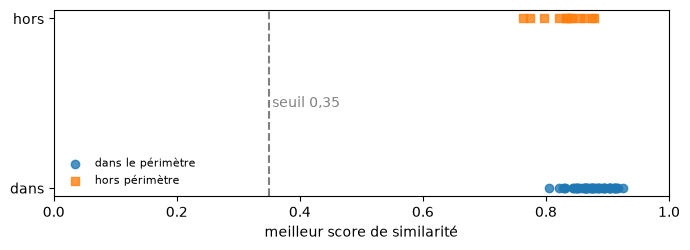

In [6]:
best = lambda q: search(q, 2)[0][1]
s_in = [best(d["question"]) for d in dataset if d["in_scope"]]
s_out = [best(d["question"]) for d in dataset if not d["in_scope"]]
print(f"dans le périmètre : {min(s_in):.3f} à {max(s_in):.3f}")
print(f"hors périmètre    : {min(s_out):.3f} à {max(s_out):.3f}")
print("hors périmètre acceptées par le seuil 0,35 :", sum(not should_refuse([s], 0.35) for s in s_out), "sur", len(s_out))

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.scatter(s_in, np.zeros(len(s_in)), label="dans le périmètre", alpha=.8)
ax.scatter(s_out, np.ones(len(s_out)), label="hors périmètre", alpha=.8, marker="s")
ax.axvline(0.35, color="grey", ls="--")
ax.text(0.355, 0.5, "seuil 0,35", color="grey", va="center")
ax.set_yticks([0, 1], ["dans", "hors"])
ax.set_xlim(0, 1)
ax.set_xlabel("meilleur score de similarité")
ax.legend(loc="lower left", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

**Constat honnête** : les questions hors périmètre obtiennent des scores aussi élevés que certaines questions dans le périmètre : les deux distributions se chevauchent. Le seuil de 0,35 ne filtre rien, et **aucun seuil ne séparerait proprement les deux groupes** sur ce jeu. Le refus repose donc surtout sur le prompt et sur la validation des citations (section suivante). Pistes : reranking, ou un classifieur de périmètre plutôt qu'un seuil sur la similarité.

## 6. Validation des citations et contrôle déterministe

Après génération, une réponse factuelle doit citer au moins un passage **réellement fourni**, sinon refus. Le contrôle des termes attendus est déterministe (sans LLM juge). Démonstration sur des réponses écrites à la main, sans appel au LLM.

In [7]:
provided = passages[:2]
good = f"Le retour est accepté sous 30 jours. [{provided[0].id}]"
invented = "Le retour est accepté sous 30 jours. [guide_inexistant.md#section-9]"
no_source = "Le retour est accepté sous 30 jours."
for label, answer in [("citation valide", good), ("citation inventée", invented), ("sans citation", no_source), ("refus", REFUSAL)]:
    print(f"{label:18} -> accepté : {validate_citations(answer, provided)}")

print()
print("termes attendus présents :", deterministic_answer_check(good, ["30 jours"]))
print("terme manquant           :", deterministic_answer_check(good, ["remboursement"]))

citation valide    -> accepté : True
citation inventée  -> accepté : False
sans citation      -> accepté : False
refus              -> accepté : True

termes attendus présents : True
terme manquant           : False


## 7. Génération avec un LLM local (Ollama)

La génération est **séparée** de la recherche. Ici : les k=2 passages les plus proches, un prompt contraint (le même que celui de l'application, `retail_rag.core.PROMPT`), Llama 3.2 3B via Ollama à température 0. Chaque réponse passe ensuite par la validation des citations et par le contrôle des termes attendus. Quelques exemples seulement : ce n'est pas une mesure de précision.

In [8]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama

by_id = {p.id: p for p in passages}
chain = ChatPromptTemplate.from_template(PROMPT) | ChatOllama(model="llama3.2", temperature=0.0) | StrOutputParser()

def answer(question, k=2):
    top = search(question, k)
    if should_refuse([s for _, s in top], 0.35):
        return REFUSAL, []
    used = [by_id[pid] for pid, _ in top]
    context = format_context(used)
    text = chain.invoke({"context": context, "question": question})
    return (text if validate_citations(text, used) else REFUSAL), used

try:
    for d in scoped[:3]:
        text, used = answer(d["question"])
        ok = deterministic_answer_check(text, d["expected_terms"])
        print("Q :", d["question"])
        print("R :", text)
        print("   termes attendus présents :", ok, "| sources :", [p.id for p in used])
        print()
except Exception as exc:
    print("Ollama indisponible :", type(exc).__name__, "- lancer `ollama serve` puis `ollama pull llama3.2`.")

Q : Quel est le délai de retour d'un article standard acheté en magasin ?
R : Le délai de retour d'un article standard acheté en magasin est de 30 jours calendaires à compter de la date d'achat. [guide_retours_echanges.md#section-1]
   termes attendus présents : True | sources : ['guide_retours_echanges.md#section-1', 'guide_retours_echanges.md#section-2']



Q : Quelles conditions doit respecter un retour standard ?
R : Un article standard doit être dans son état d'origine, non porté, non utilisé et accompagné de ses étiquettes lorsqu'elles étaient présentes lors de l'achat [guide_retours_echanges.md#section-1].
   termes attendus présents : False | sources : ['guide_retours_echanges.md#section-1', 'guide_retours_echanges.md#section-7']



Q : Quel est le délai de retour d'un article soldé ?
R : Information non trouvée dans les documents.
   termes attendus présents : False | sources : ['guide_retours_echanges.md#section-3', 'guide_retours_echanges.md#section-1']



Cette étape reste **le maillon le plus fragile** : un petit modèle peut mal lire un passage ou mélanger deux règles. C'est pourquoi le refus et les citations sont contrôlés par du code, pas par le modèle, et pourquoi aucune précision de génération n'est revendiquée.

## 8. Limites et pistes

- Corpus fictif de 8 guides courts (50 passages) ; documents réels (PDF, tableaux, versions contradictoires) non testés.
- 65 questions écrites par l'auteur du corpus, y compris les questions difficiles : biais possible.
- Seuil de refus inopérant : les scores dans et hors périmètre se chevauchent (voir section 5).
- Aucune évaluation humaine de la fidélité ; la validation des citations prouve qu'un identifiant existe, pas que l'affirmation est vraie.
- Llama 3.2 3B (Ollama) choisi pour le coût et le fonctionnement local, pas pour une précision de production.

Pistes : jeu d'évaluation plus large et rédigé par d'autres, comparaison de modèles d'embeddings, recherche hybride (BM25 + vecteurs) et reranking, calibration du seuil, relecture humaine à l'aveugle des réponses.